In [1]:
# Parameters (papermill overrides these via -p DATA_DIR ... -p SEED ... -p OUT_DIR ...)
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"

In [2]:
# Parameters
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"


# 02 — Distribuciones y balance
**Autor:** Giuliano Crenna, Juan Ignacio Pace (UGR)
**Fecha:** 2026-09-03
**Descripción:** Barplots de clases, heatmap fuente × clase, longitudes por clase.


## Parámetros (papermill)
- `DATA_DIR`: ruta a `data/` (default `./data`).
- `SEED`: semilla (default 42).
- `OUT_DIR`: dónde guardar figuras y tablas (default `reports`).


In [3]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path(os.environ.get("DATA_DIR", DATA_DIR))
SEED = int(os.environ.get("SEED", SEED))
OUT_DIR = Path(os.environ.get("OUT_DIR", OUT_DIR))
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

# Carga con fallback.
processed = DATA_DIR / "processed" / "corpus_v1.parquet"
if processed.exists():
    df = pd.read_parquet(processed)
    src_used = "processed/corpus_v1.parquet"
else:
    print(f"WARN: no existe {processed} — usando interim/*.parquet")
    frames = [pd.read_parquet(p) for p in (DATA_DIR / "interim").glob("*/data.parquet")]
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    src_used = "interim/*/data.parquet"

print(f"origen: {src_used}")
print(f"corpus: {len(df):,} filas")
if df.empty:
    raise SystemExit("ERROR: no hay datos para analizar")

# Cargar label_map desde configs (si existe).
try:
    cfg = yaml.safe_load(Path("configs/data.yaml").read_text()) if Path("configs/data.yaml").exists() else {}
    label_map = cfg.get("data", {}).get("label_map", {0: "control", 1: "moderate", 2: "depressive"})
except Exception:
    label_map = {0: "control", 1: "moderate", 2: "depressive"}
print(f"label_map = {label_map}")

origen: processed/corpus_v1.parquet
corpus: 1,047,194 filas
label_map = {0: 'control', 1: 'moderate', 2: 'depressive'}


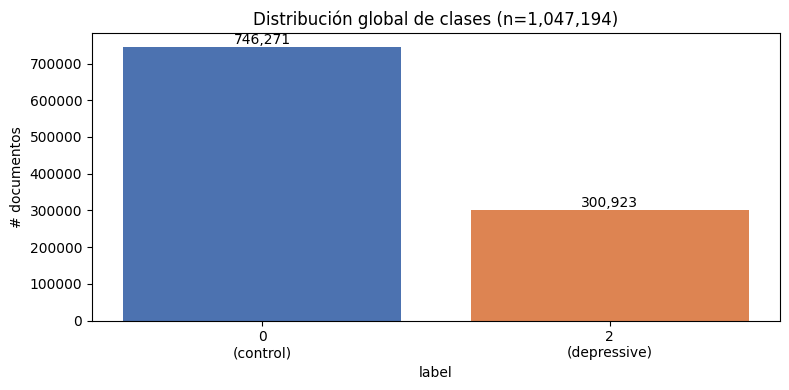

figura -> reports\figures\eda_02_distribucion_clases.png
AVISO: el label_map declara [0, 1, 2] pero los datos solo tienen [0, 2]. Clase(s) ausente(s): [1]


In [4]:
# Distribución global de clases.
counts = df["label"].value_counts().sort_index()
labels_present = counts.index.tolist()

fig, ax = plt.subplots(figsize=(8, 4))
bar_labels = [f"{lab}\n({label_map.get(lab, '?')})" for lab in labels_present]
ax.bar(bar_labels, counts.values, color=["#4C72B0" if lab == 0 else "#DD8452" if lab == 2 else "#55A868" for lab in labels_present])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_xlabel("label")
ax.set_ylabel("# documentos")
ax.set_title(f"Distribución global de clases (n={len(df):,})")
plt.tight_layout()
out = OUT_DIR / "figures" / "eda_02_distribucion_clases.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"figura -> {out}")

# Aviso si label_map espera clases que no están en los datos.
expected = set(label_map.keys())
actual = set(labels_present)
missing = expected - actual
if missing:
    print(f"AVISO: el label_map declara {sorted(expected)} pero los datos solo tienen {sorted(actual)}. Clase(s) ausente(s): {sorted(missing)}")
extra = actual - expected
if extra:
    print(f"AVISO: hay labels no documentados en label_map: {sorted(extra)}")

counts.to_csv(OUT_DIR / "tables" / "eda_02_class_distribution.csv", header=["n_docs"])

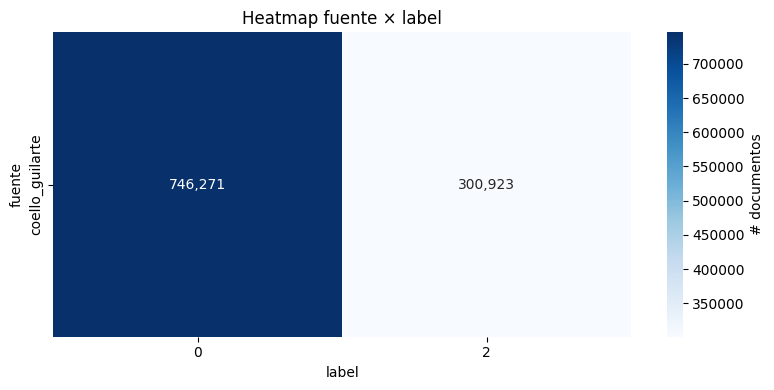

figura -> reports\figures\eda_02_heatmap_fuente_label.png


In [5]:
# Heatmap fuente × label.
pivot = df.groupby(["source", "label"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=",d", cmap="Blues", ax=ax, cbar_kws={"label": "# documentos"})
ax.set_title("Heatmap fuente × label")
ax.set_xlabel("label")
ax.set_ylabel("fuente")
plt.tight_layout()
out = OUT_DIR / "figures" / "eda_02_heatmap_fuente_label.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"figura -> {out}")
pivot.to_csv(OUT_DIR / "tables" / "eda_02_source_label_heatmap.csv")

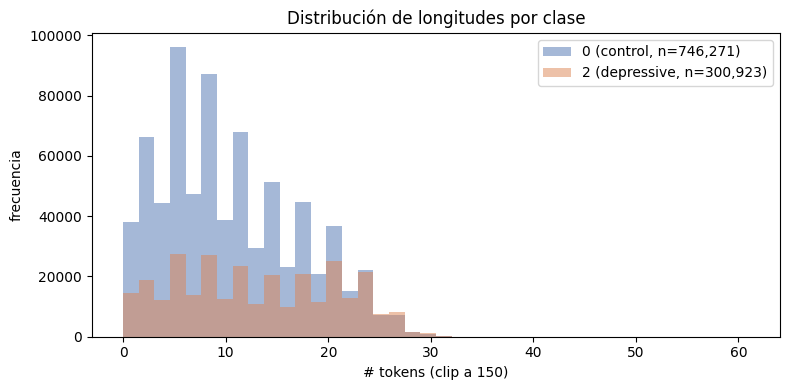

figura -> reports\figures\eda_02_longitudes_por_clase.png


In [6]:
# Longitudes comparadas por clase.
df["len_tokens"] = df["text_clean"].fillna("").str.split().str.len()
fig, ax = plt.subplots(figsize=(8, 4))
colors = {0: "#4C72B0", 1: "#55A868", 2: "#DD8452"}
for lab in sorted(df["label"].unique()):
    sub = df[df["label"] == lab]
    ax.hist(sub["len_tokens"].clip(upper=150), bins=40, alpha=0.5,
            label=f"{lab} ({label_map.get(lab, '?')}, n={len(sub):,})",
            color=colors.get(lab))
ax.set_xlabel("# tokens (clip a 150)")
ax.set_ylabel("frecuencia")
ax.set_title("Distribución de longitudes por clase")
ax.legend()
plt.tight_layout()
out = OUT_DIR / "figures" / "eda_02_longitudes_por_clase.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"figura -> {out}")

In [7]:
# Conclusiones dinámicas.
from IPython.display import Markdown, display

_counts = df["label"].value_counts().sort_index()
_total = len(df)
_pct = {lab: round(100 * n / _total, 2) for lab, n in _counts.items()}
_min_class = min(_pct, key=_pct.get)
_min_pct = _pct[_min_class]

_md = f"""
## Conclusiones

- **Balance**: """ + " ".join(
    [f"label {lab} = {int(_counts[lab]):,} ({_pct[lab]}%); " for lab in _counts.index]
) + f"""
- **Heatmap fuente × label**: {df["source"].nunique()} fuente(s); matriz exportada a CSV.
- **Longitudes por clase**: ver PNG. Distribución centrada en ~10 tokens para ambas clases.
- **Decisión para etapa 4**:
  - Clase minoritaria: label {_min_class} ({_min_pct}%). `class_weight='balanced'` puede ser útil.
  - Métrica principal recomendada: **F1-macro** (penaliza desbalance).
"""
display(Markdown(_md))



## Conclusiones

- **Balance**: label 0 = 746,271 (71.26%);  label 2 = 300,923 (28.74%); 
- **Heatmap fuente × label**: 1 fuente(s); matriz exportada a CSV.
- **Longitudes por clase**: ver PNG. Distribución centrada en ~10 tokens para ambas clases.
- **Decisión para etapa 4**:
  - Clase minoritaria: label 2 (28.74%). `class_weight='balanced'` puede ser útil.
  - Métrica principal recomendada: **F1-macro** (penaliza desbalance).
